In [ ]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import lisaps
from lisaps.baseclasses import DataContainer, BaseNoise
from lisaps.constants import YRSID_SI
import numpy as np
import matplotlib.pyplot as plt

In [2]:
T, dt = 1.0, 5.0
noisekwargs = dict(
    filtered=False,
    scirdv1=True,
    T=T,
    fs = 1.0 / dt,
)

noisemodel = BaseNoise(**noisekwargs)

Using default armlength: 8.3391023799538


In [ ]:
t = np.arange(0, T*YRSID_SI, dt)

freqs = np.fft.rfftfreq(len(t), d=dt)[1:]

In [ ]:
datagenerator = lisaps.utils.NoiseGenerator(noise_kwargs=noisekwargs, domain="frequency")

data = datagenerator(freqs=freqs, psd_kwargs=dict(squeeze=True, out=True))

Using default armlength: 8.3391023799538


In [ ]:
aet_data = data[:, 1:] # the first entry is frequency

## We have different ways to smooth the input data

In [ ]:
fmin, fmax = 1e-4, 2.9e-2
average = False

datacontainer_nosmooth = DataContainer(
                        t=None,
                        d=None,
                        freqs=freqs,
                        dtilde=aet_data,
                        fmin=fmin,
                        fmax=fmax,
                        nchannels=3,
                        average=False,
                    )


In [ ]:
datacontainer_static = DataContainer(
                        t=None,
                        d=None,
                        freqs=freqs,
                        dtilde=aet_data,
                        fmin=fmin,
                        fmax=fmax,
                        nchannels=3,
                        average=True,
                        average_kwargs=dict(f_seg=1e-5),
)

In [ ]:
datacontainer_adaptive = DataContainer(
                        t=None,
                        d=None,
                        freqs=freqs,
                        dtilde=aet_data,
                        fmin=fmin,
                        fmax=fmax,
                        nchannels=3,
                        average='adaptive',
                        average_kwargs=dict(min_bpd=100, max_bpd=500, order='increasing'),
)

In [ ]:
noisepsd = noisemodel.set_PSDS(freqs=freqs, squeeze=True, out=True)

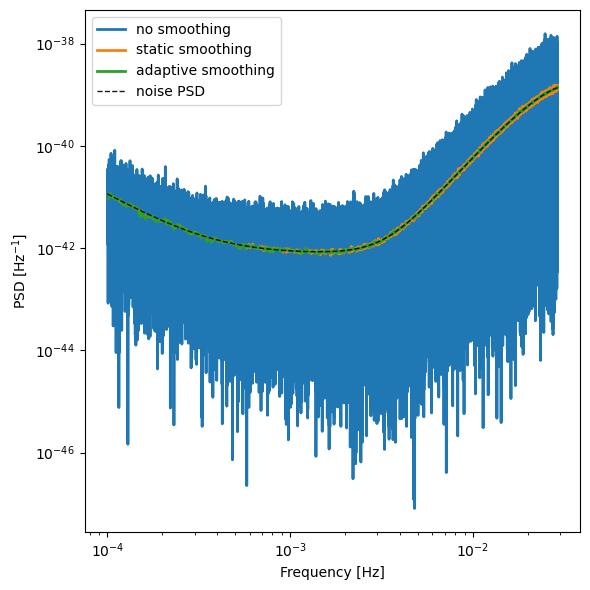

In [ ]:
freqmask = (freqs >= fmin) & (freqs <= fmax)

fig, axs = datacontainer_nosmooth.loglog(channels=[0,], label='no smoothing', lw=2)
datacontainer_static.loglog(fig, axs=axs, channels=[0,], label='static smoothing', lw=2)
datacontainer_adaptive.loglog(fig, axs=axs, channels=[0,], label='adaptive smoothing', lw=2)

for i, ax in enumerate(axs):
    ax.loglog(freqs[freqmask], noisepsd[freqmask, i], c='k', ls='--', label='noise PSD', alpha=0.9, lw=1)

axs[0].legend()

plt.show()

## number of frequencies inside each bin

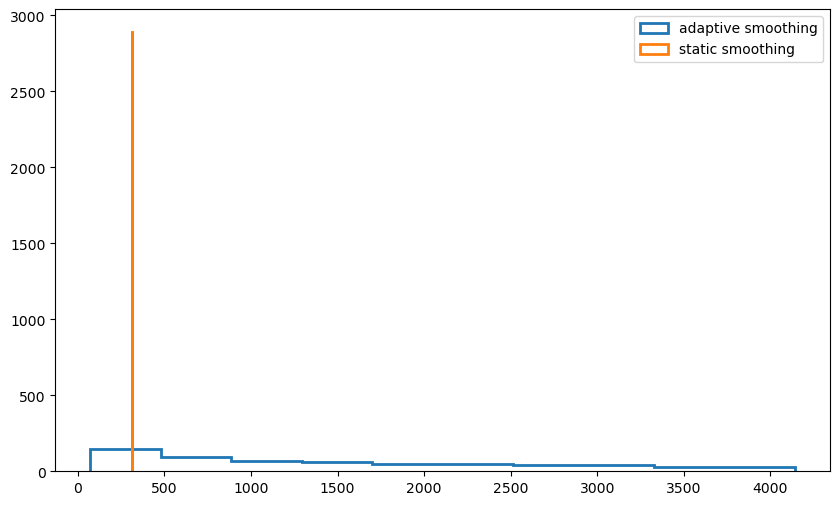

In [ ]:
fig = plt.figure(figsize=(10, 6))
plt.hist(datacontainer_adaptive.nu, histtype='step', label='adaptive smoothing', lw=2)
plt.hist(datacontainer_static.nu, histtype='step', label='static smoothing', lw=2)

plt.legend()
plt.show()